In [1]:
import utils_FaIR_JAX
import utils_inverse
import matplotlib.pyplot as plt
import jax

## Setup plots
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({
  "text.usetex": True,
  "font.family": "sans-serif",
  "font.sans-serif": ["Helvetica Light"],
})

%load_ext autoreload
%autoreload 2

# Use inverse model to find optimal emissions time series for CH<sub>4</sub>
Spatial invariance as future work - requires a fully differentiable model. Use Maren's test cases as examples for other targets to optimize over.

## 1. Verify LSTM framework and generate baseline emulator

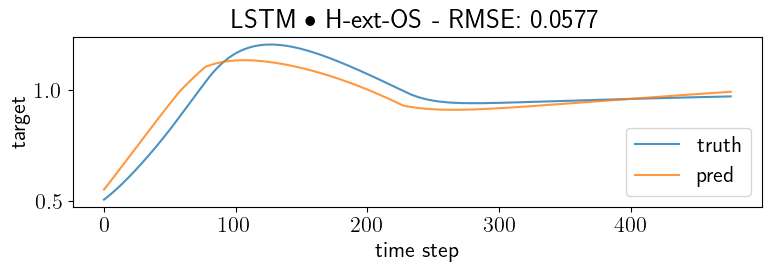

||grad BC||: 0.0
||grad CH4||: 1.9410360607707844e-07
||grad CO2||: 0.0
||grad N2O||: 0.0
||grad Sulfur||: 0.0


In [2]:
agents = ['CH4']
emis_dict_calib_FaIR, emis_dict_calib_JAX, delT_dict_calib_FaIR, delT_dict_calib_JAX = utils_FaIR_JAX.generate_calib_data(agents)
emis_dict_train_FaIR, emis_dict_test_FaIR, emis_dict_train_JAX, emis_dict_test_JAX, delT_dict_train_FaIR, delT_dict_test_FaIR, delT_dict_train_JAX, delT_dict_test_JAX = utils_FaIR_JAX.generate_train_test(agents)

train_data = utils_inverse.build_dataset_from_runfair_dict(emis_dict_train_JAX)
test_data = utils_inverse.build_dataset_from_runfair_dict(emis_dict_test_JAX)
train_s, test_s, stats = utils_inverse.split_and_scale(train_data, test_data)

idx_demo = 1
params0 = utils_inverse.create_baseline(train_s, test_s, idx_demo, verbose=False)

test_scen = 'historical'
utils_inverse.test_get_grad(test_scen, params0, emis_dict_train_JAX, train_data, test_data, active=("CH4"))

## 2. Optimize CH<sub>4</sub> emissions time series used in training

### 2a. Train baseline emulator on ScenarioMIP tier 1

In [3]:
emis_dict_tier1_JAX, emis_dict_tier2_JAX, emis_dict_DECK_JAX, emis_dict_CS3_JAX = utils_FaIR_JAX.generate_JAX_data(agents, CS3=True)
emis_dict_all_JAX = emis_dict_tier1_JAX | emis_dict_tier2_JAX | emis_dict_DECK_JAX | emis_dict_CS3_JAX
test_sets = {
    "Tier 1": emis_dict_tier1_JAX,
    "Tier 2": emis_dict_tier2_JAX,
    "DECK": emis_dict_DECK_JAX,
    "CS3": emis_dict_CS3_JAX,
    "All": emis_dict_all_JAX
}

In [4]:
paramsK_base, baseline_results, baseline_preds, ground_truth = utils_inverse.evaluate_baseline_over_multiple_tests(
    emis_dict_train=emis_dict_tier1_JAX,
    test_sets=test_sets,
    historical_name="historical",
    key=jax.random.PRNGKey(0),
    hidden=32,
    K=400,
    lr=5e-2,
    weight_decay=1e-2,
)

import pickle
path = 'checkpoints/ch4/baseline_ch4_only.pkl'

with open(path, "wb") as f:
    pickle.dump(baseline_results, f)

for test_set in baseline_results:
    per_scen = baseline_results[test_set]
    mean_err = baseline_results[test_set]['mean']
    print(f"\n{test_set} mean scaled RMSE: {mean_err:.4f}")
    for scen, val in per_scen.items():
        if scen == 'mean':
            continue
        print(f"  {scen:30s}  {val:.4f}")


Tier 1 mean scaled RMSE: 0.0537
  historical                      0.0766
  H-ext                           0.0479
  M                               0.0349
  ML                              0.0349
  L                               0.0649
  VLLO-ext                        0.0492
  VLHO                            0.0675

Tier 2 mean scaled RMSE: 0.0513
  historical                      0.0766
  H-ext-OS                        0.0479
  M-ext                           0.0431
  ML-ext                          0.0431
  L-ext                           0.0480
  VLHO-ext                        0.0492

DECK mean scaled RMSE: 0.0954
  abrupt-4xCH4                    0.1183
  1pctCH4                         0.0725

CS3 mean scaled RMSE: 0.0666
  AA                              0.0574
  CT                              0.0512
  historical                      0.0912

All mean scaled RMSE: 0.0589
  historical                      0.0912
  H-ext                           0.0487
  M                    

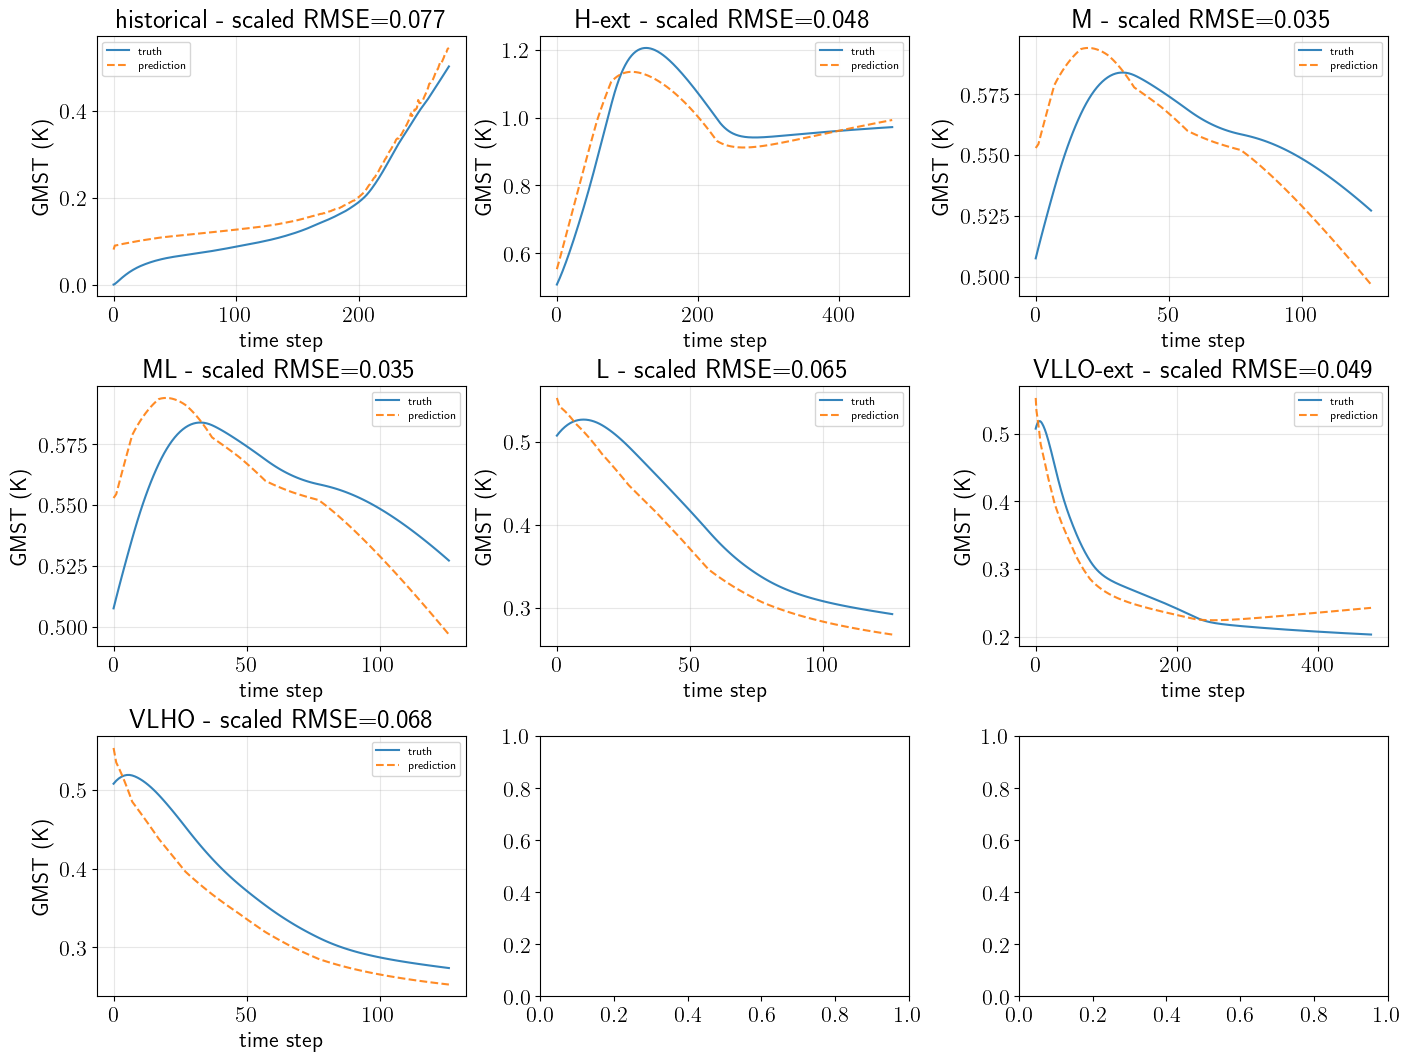

In [5]:
import numpy as np
test_set = 'Tier 1'
N_scens = len(baseline_results[test_set])
rows = int(np.ceil(N_scens / 3))
cols = 3
fig, axes = plt.subplots(rows, cols, figsize=(14, 3.5*rows), constrained_layout=True)
axes = axes.ravel()

for i, scen in enumerate(baseline_results[test_set]):
    if scen == 'mean':
        continue
    ax = axes[i]
    ax.plot(ground_truth[test_set][scen],  label="truth", alpha=0.9)
    ax.plot(baseline_preds[test_set][scen],  label="prediction", ls="--", alpha=0.9)
    ax.set_title(f"{scen} - scaled RMSE={baseline_results[test_set][scen]:.3f}")
    ax.set_xlabel("time step")
    ax.set_ylabel("GMST (K)")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=8)

### 2b. Optimize for H-ext, starting from H-ext initial condition (sanity check)

In [506]:
emis_dict_valid = {}
#emis_dict_valid['H-ext'] = jnp.concat([emis_dict_train_JAX['historical'].copy(), emis_dict_train_JAX['H-ext'].copy()], axis=1)
emis_dict_valid['H-ext'] = emis_dict_train_JAX['H-ext'].copy()
emis_dict_valid['historical'] = emis_dict_train_JAX['historical'].copy()

results_CO2_trivial = utils_inverse.optimize_emissions_inverse(
    emis_dict=emis_dict_valid,
    params0=params0,
    num_updates=2,
    step_size=1e3,
    momentum=0.9,
    nesterov=True,
    K_inner=400,
    lr_inner=5e-2,
    wd_inner=1e-2,
    checkpoint_path="checkpoints/co2/inverse_H-ext_co2_only.pkl",
    checkpoint_every=5,
    resume_if_exists=False,
    save_preds=True,
    preds_every=1,
    save_preds_in_ckpt=True,
    agents=("CO2","CH4"),
    active_agents=("CO2",),
    init_spec=emis_dict_valid['H-ext'],
    inactive_mode="zeros",
    T=477,
)

No checkpoint found, starting fresh...


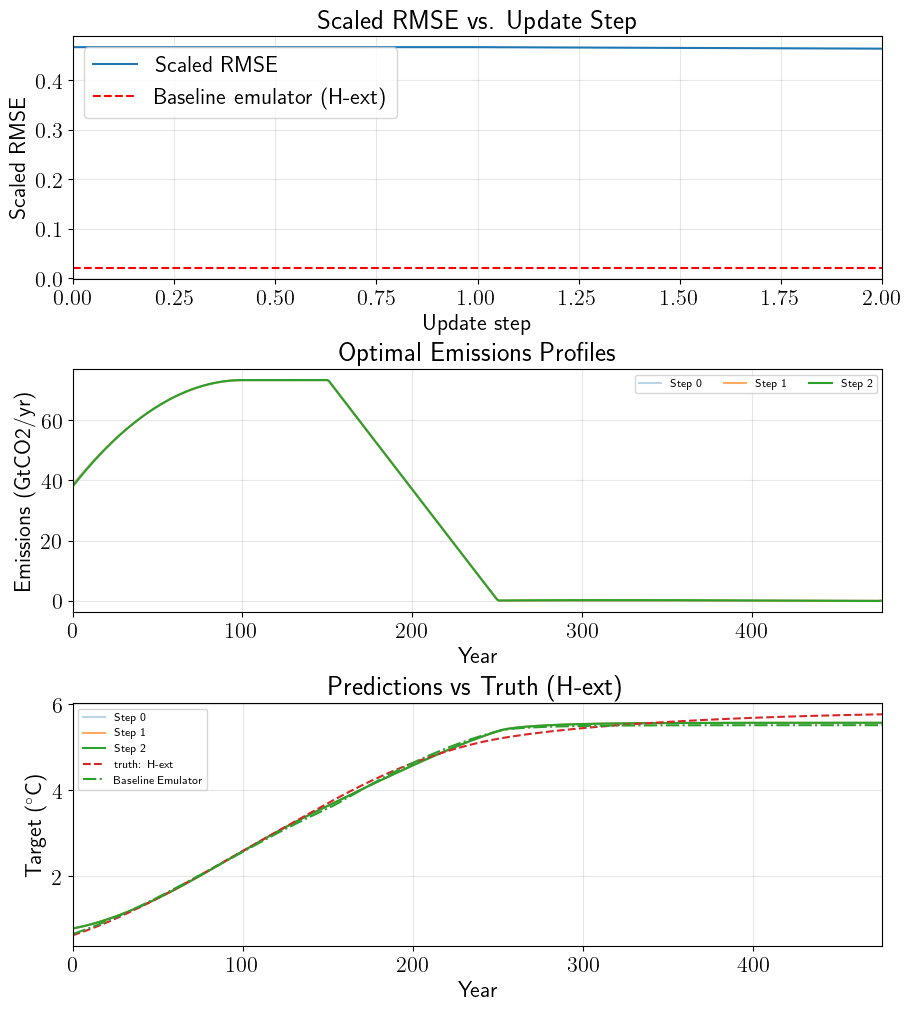

In [507]:
predict_plot = 'H-ext'
utils_inverse.plot_inverse_results(
    results_CO2_trivial,
    baseline_results['Tier 1'][predict_plot],
    active_agents=('CO2',),
    pred_scenario=predict_plot,
    baseline_preds=baseline_preds['Tier 1'][predict_plot]
)

### 2c. Optimize training data for predictive skill over ScenarioMIP tier 1, starting from constant, ramp, and Gaussian ICs

In [4]:
emis_dicts_valid = [(emis_dict_tier1_JAX.copy(), 'tier1'),
                    (emis_dict_tier2_JAX.copy(), 'tier2'),
                    (emis_dict_DECK_JAX.copy(), 'DECK'),
                    (emis_dict_CS3_JAX.copy(), 'CS3'),
                    (emis_dict_all_JAX.copy(), 'all')]
IC = 'constant'

for emis_dict, group in emis_dicts_valid:
    print(f'Optimizing over {group}')
    results_CH4_constant = utils_inverse.optimize_emissions_inverse(
        emis_dict=emis_dict,
        params0=params0,
        num_updates=1000,
        step_size=1e5,
        momentum=0.9,
        nesterov=True,
        K_inner=400,
        lr_inner=5e-2,
        wd_inner=1e-2,
        checkpoint_path=f"checkpoints/ch4/inverse_{IC}_{group}_ch4_only.pkl",
        checkpoint_every=50,
        resume_if_exists=True,
        preds_every=50,
        active_agents=("CH4",),
        init_spec=IC,
        inactive_mode="zeros",
        T=751,
        n_nonneg_prefix=0,
    )

Optimizing over tier1
Resuming from checkpoint...
Optimizing over tier2
Resuming from checkpoint...
Optimizing over DECK
Resuming from checkpoint...
Optimizing over CS3
Resuming from checkpoint...
Optimizing over all
Starting fresh...


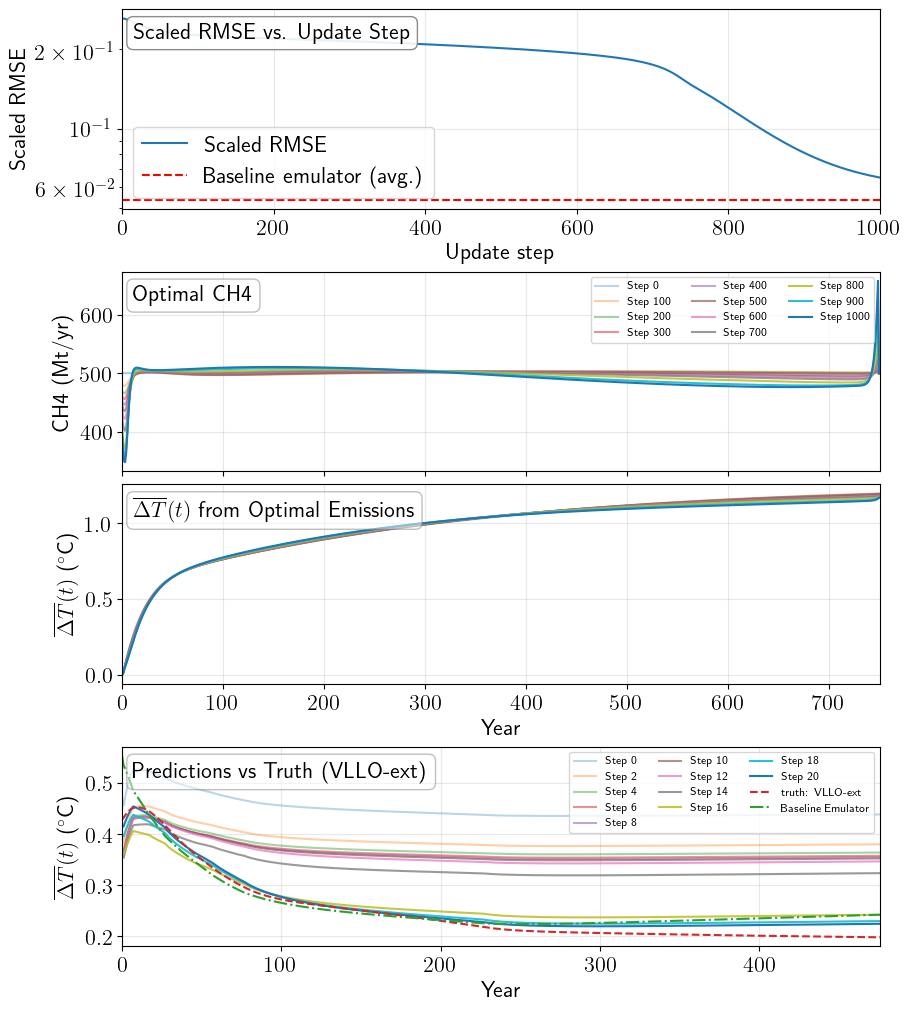

In [7]:
predict_plot = 'VLLO-ext'
utils_inverse.plot_inverse_results(
    results_CH4_constant,
    baseline_results['Tier 1']['mean'],
    active_agents=('CH4',),
    pred_scenario=predict_plot,
    baseline_preds=baseline_preds['Tier 1'][predict_plot]
)

In [6]:
emis_dict_valid = emis_dict_tier1_JAX.copy()
IC = 'constant'
targets = ['tier1','tier2','DECK','all']

for i, emis_dict_valid in enumerate([emis_dict_tier1_JAX, emis_dict_tier2_JAX, emis_dict_DECK_JAX, emis_dict_calib_JAX]):
  t = targets[i]
  print(f'Optimizing for {t}...')
  for IC in ['constant','ramp','gaussian']:
    print(f'\t IC = {IC}')
    results_CH4 = utils_inverse.optimize_emissions_inverse(
        emis_dict=emis_dict_valid,
        params0=params0,
        num_updates=500,
        step_size=1e5,
        momentum=0.9,
        nesterov=True,
        K_inner=400,
        lr_inner=5e-2,
        wd_inner=1e-2,
        checkpoint_path=f"checkpoints/ch4/inverse_{IC}_{t}_ch4_only.pkl",
        checkpoint_every=5,
        resume_if_exists=True,
        preds_every=1,
        active_agents=("CH4",),
        init_spec=IC,
        inactive_mode="zeros",
        T=751,
        n_nonneg_prefix=0,
    )

Optimizing for tier1...
	 IC = constant
Found 500 updates in checkpoint, starting from here...
	 IC = ramp
Found 500 updates in checkpoint, starting from here...
	 IC = gaussian
Found 500 updates in checkpoint, starting from here...
Optimizing for tier2...
	 IC = constant
Found 500 updates in checkpoint, starting from here...
	 IC = ramp
Found 500 updates in checkpoint, starting from here...
	 IC = gaussian
Found 500 updates in checkpoint, starting from here...
Optimizing for DECK...
	 IC = constant
Found 500 updates in checkpoint, starting from here...
	 IC = ramp
Found 500 updates in checkpoint, starting from here...
	 IC = gaussian
Found 500 updates in checkpoint, starting from here...
Optimizing for all...
	 IC = constant
Found 500 updates in checkpoint, starting from here...
	 IC = ramp
No checkpoint found, starting fresh...
	 IC = gaussian
No checkpoint found, starting fresh...


In [7]:
emis_dict_valid = emis_dict_tier1_JAX.copy()
IC = 'ramp'

results_CH4_tier1_ramp = utils_inverse.optimize_emissions_inverse(
    emis_dict=emis_dict_valid,
    params0=params0,
    num_updates=500,
    step_size=1e3,
    momentum=0.9,
    nesterov=True,
    K_inner=400,
    lr_inner=5e-2,
    wd_inner=1e-2,
    checkpoint_path=f"checkpoints/ch4/inverse_{IC}_tier1_ch4_only.pkl",
    checkpoint_every=5,
    resume_if_exists=True,
    preds_every=1,
    active_agents=("CH4",),
    init_spec=IC,
    inactive_mode="zeros",
    T=751,
    n_nonneg_prefix=0,
)

Found 500 updates in checkpoint, starting from here...


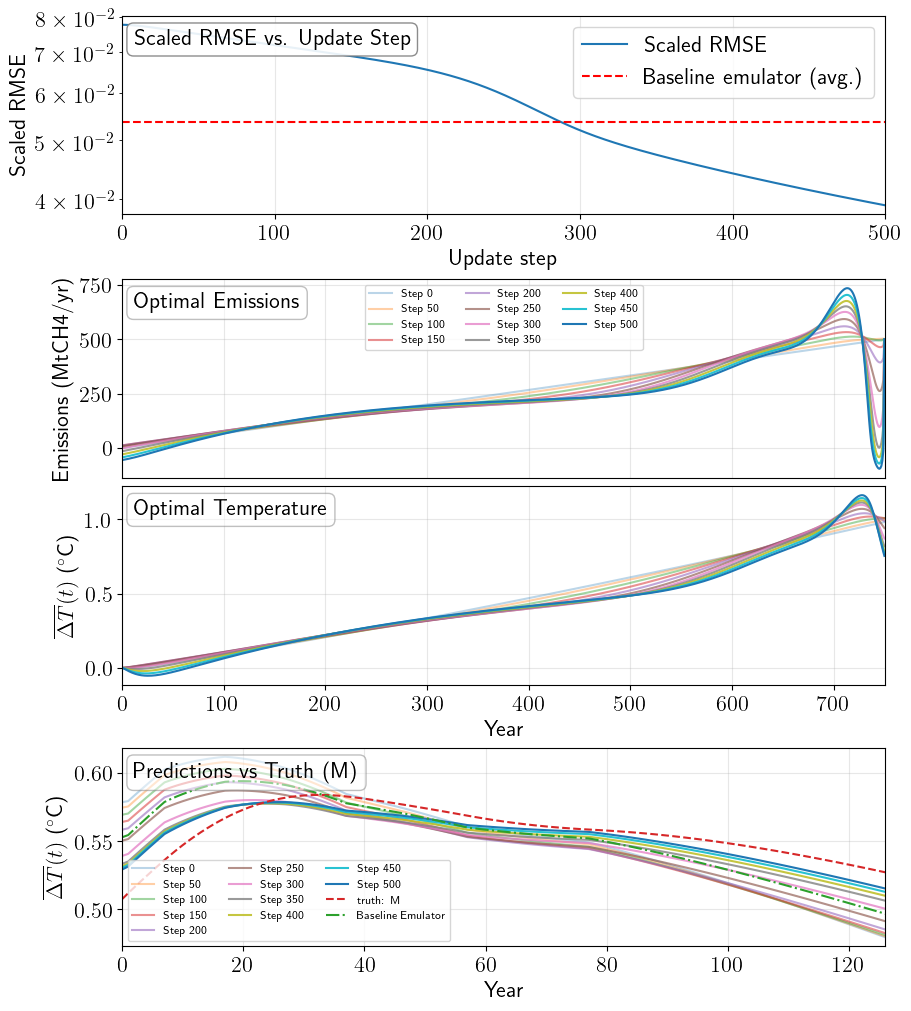

In [10]:
predict_plot = 'M'
utils_inverse.plot_inverse_results(
    results_CH4_tier1_ramp,
    baseline_results['Tier 1']['mean'],
    active_agents=('CH4',),
    pred_scenario=predict_plot,
    baseline_preds=baseline_preds['Tier 1'][predict_plot]
)

In [11]:
emis_dict_valid = emis_dict_tier1_JAX.copy()
IC = 'gaussian'

results_CH4_tier1_gaussian = utils_inverse.optimize_emissions_inverse(
    emis_dict=emis_dict_valid,
    params0=params0,
    num_updates=500,
    step_size=1e3,
    momentum=0.9,
    nesterov=True,
    K_inner=400,
    lr_inner=5e-2,
    wd_inner=1e-2,
    checkpoint_path=f"checkpoints/ch4/inverse_{IC}_tier1_ch4_only.pkl",
    checkpoint_every=5,
    resume_if_exists=True,
    preds_every=1,
    active_agents=("CH4",),
    init_spec=IC,
    inactive_mode="zeros",
    T=751,
    n_nonneg_prefix=0,
)

Found 500 updates in checkpoint, starting from here...


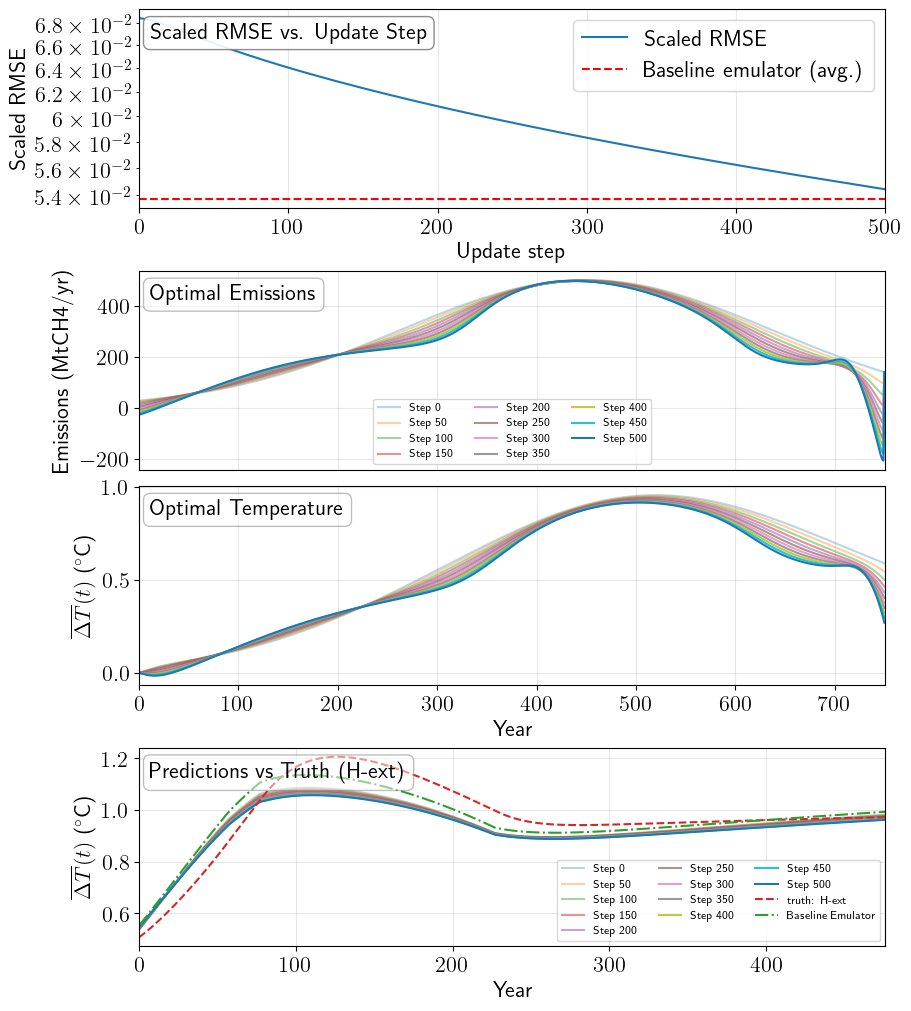

In [12]:
predict_plot = 'H-ext'
utils_inverse.plot_inverse_results(
    results_CH4_tier1_gaussian,
    baseline_results['Tier 1']['mean'],
    active_agents=('CH4',),
    pred_scenario=predict_plot,
    baseline_preds=baseline_preds['Tier 1'][predict_plot]
)

### 2d. Optimize training data for predictive skill over ScenarioMIP tier 2, starting from constant, ramp, and Gaussian ICs

In [13]:
emis_dict_valid = emis_dict_tier2_JAX.copy()
IC = 'constant'

results_CH4_tier2_constant = utils_inverse.optimize_emissions_inverse(
    emis_dict=emis_dict_valid,
    params0=params0,
    num_updates=500,
    step_size=1e3,
    momentum=0.9,
    nesterov=True,
    K_inner=400,
    lr_inner=5e-2,
    wd_inner=1e-2,
    checkpoint_path=f"checkpoints/ch4/inverse_{IC}_tier2_ch4_only.pkl",
    checkpoint_every=5,
    resume_if_exists=True,
    preds_every=1,
    active_agents=("CH4",),
    init_spec=IC,
    inactive_mode="zeros",
    T=751,
)

Found 500 updates in checkpoint, starting from here...


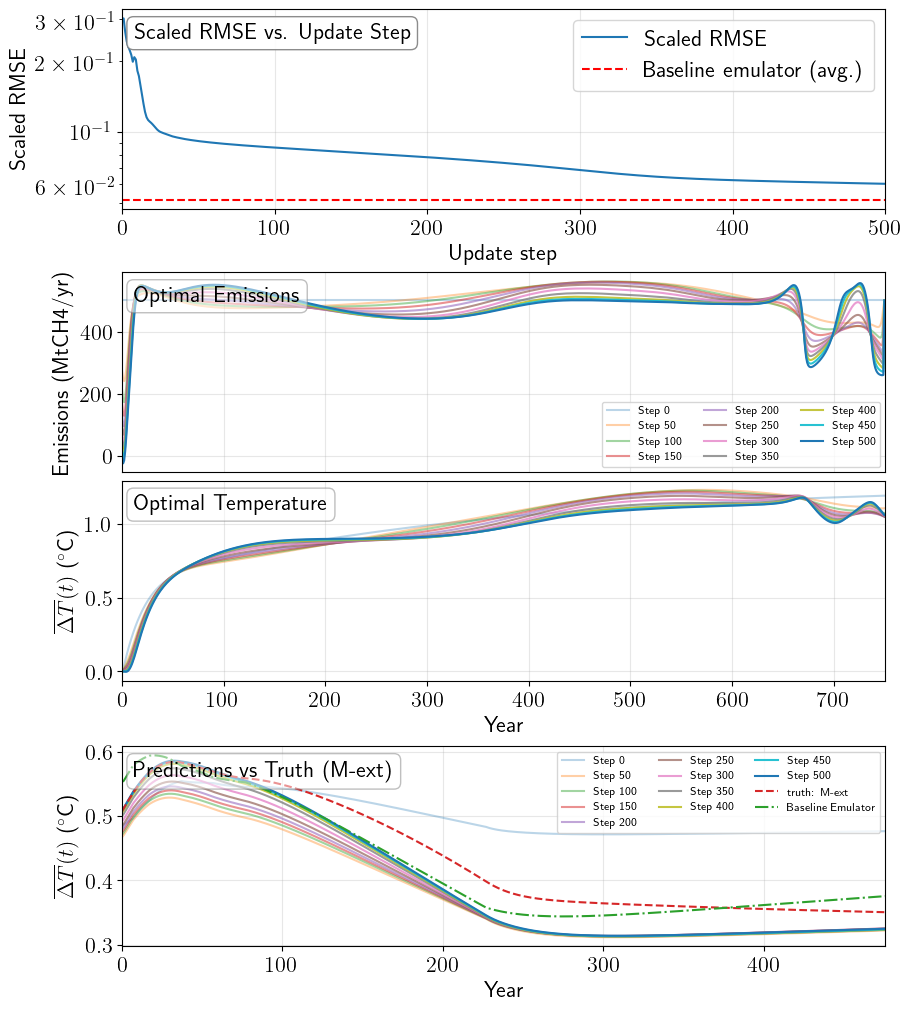

In [15]:
predict_plot = 'M-ext'
utils_inverse.plot_inverse_results(
    results_CH4_tier2_constant,
    baseline_results['Tier 2']['mean'],
    active_agents=('CH4',),
    pred_scenario=predict_plot,
    baseline_preds=baseline_preds['Tier 2'][predict_plot]
)

In [16]:
emis_dict_valid = emis_dict_tier2_JAX.copy()
IC = 'ramp'

results_CH4_tier2_ramp = utils_inverse.optimize_emissions_inverse(
    emis_dict=emis_dict_valid,
    params0=params0,
    num_updates=500,
    step_size=1e3,
    momentum=0.9,
    nesterov=True,
    K_inner=400,
    lr_inner=5e-2,
    wd_inner=1e-2,
    checkpoint_path=f"checkpoints/ch4/inverse_{IC}_tier2_ch4_only.pkl",
    checkpoint_every=5,
    resume_if_exists=True,
    preds_every=1,
    active_agents=("CH4",),
    init_spec=IC,
    inactive_mode="zeros",
    T=751,
)

Found 500 updates in checkpoint, starting from here...


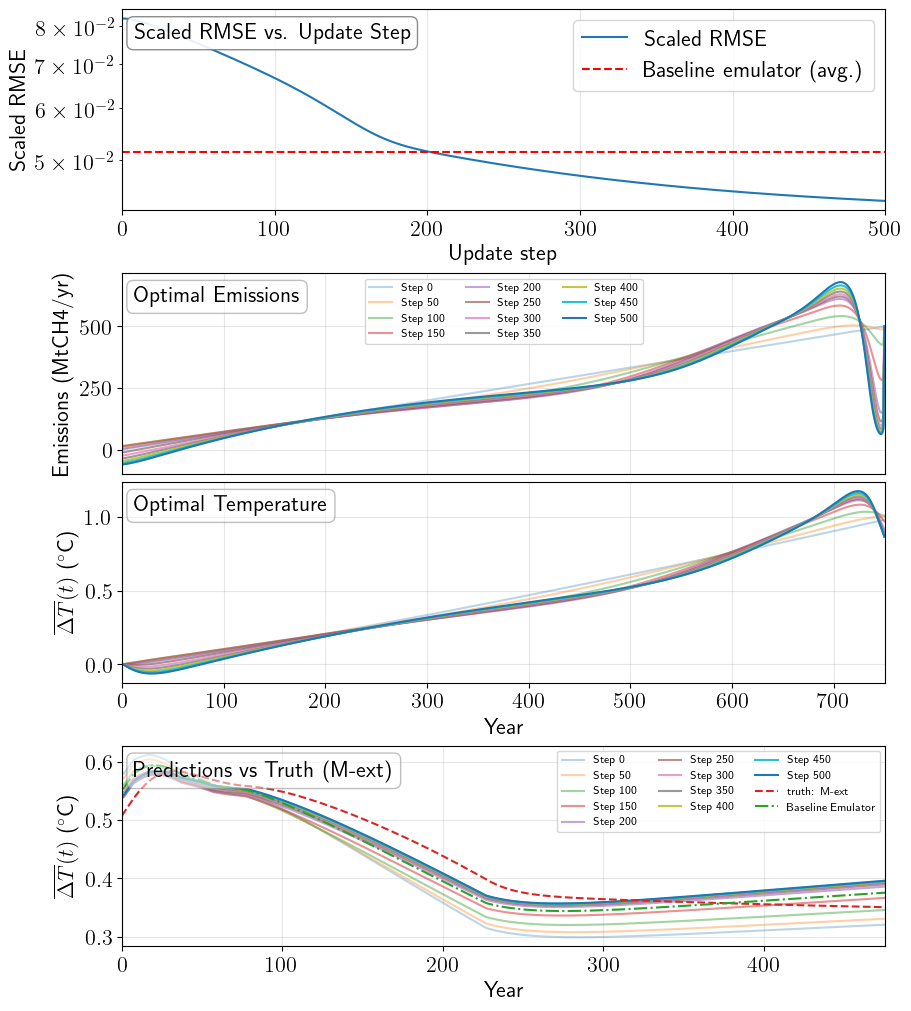

In [17]:
predict_plot = 'M-ext'
utils_inverse.plot_inverse_results(
    results_CH4_tier2_ramp,
    baseline_results['Tier 2']['mean'],
    active_agents=('CH4',),
    pred_scenario=predict_plot,
    baseline_preds=baseline_preds['Tier 2'][predict_plot]
)

In [18]:
emis_dict_valid = emis_dict_tier2_JAX.copy()
IC = 'gaussian'

results_CH4_tier2_gaussian = utils_inverse.optimize_emissions_inverse(
    emis_dict=emis_dict_valid,
    params0=params0,
    num_updates=500,
    step_size=1e3,
    momentum=0.9,
    nesterov=True,
    K_inner=400,
    lr_inner=5e-2,
    wd_inner=1e-2,
    checkpoint_path=f"checkpoints/ch4/inverse_{IC}_tier2_ch4_only.pkl",
    checkpoint_every=5,
    resume_if_exists=True,
    preds_every=1,
    active_agents=("CH4",),
    init_spec=IC,
    inactive_mode="zeros",
    T=751,
)

Found 500 updates in checkpoint, starting from here...


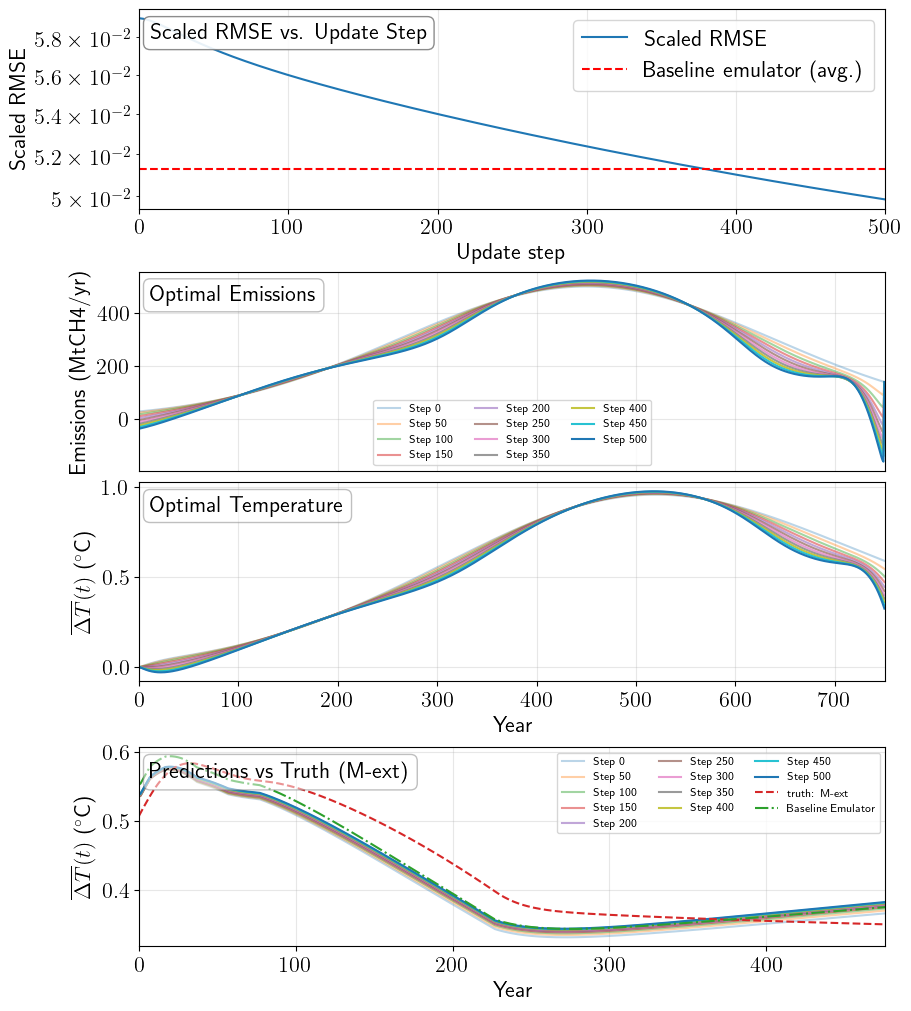

In [19]:
predict_plot = 'M-ext'
utils_inverse.plot_inverse_results(
    results_CH4_tier2_gaussian,
    baseline_results['Tier 2']['mean'],
    active_agents=('CH4',),
    pred_scenario=predict_plot,
    baseline_preds=baseline_preds['Tier 2'][predict_plot]
)

### 2e. Optimize training data for predictive skill over DECK, starting from constant, ramp, and Gaussian ICs

In [20]:
emis_dict_valid = emis_dict_DECK_JAX.copy()
IC = 'constant'

results_CH4_DECK_constant = utils_inverse.optimize_emissions_inverse(
    emis_dict=emis_dict_valid,
    params0=params0,
    num_updates=500,
    step_size=1e3,
    momentum=0.9,
    nesterov=True,
    K_inner=400,
    lr_inner=5e-2,
    wd_inner=1e-2,
    checkpoint_path=f"checkpoints/ch4/inverse_{IC}_DECK_ch4_only.pkl",
    checkpoint_every=5,
    resume_if_exists=True,
    preds_every=1,
    active_agents=("CH4",),
    init_spec=IC,
    inactive_mode="zeros",
    T=751,
)

Found 500 updates in checkpoint, starting from here...


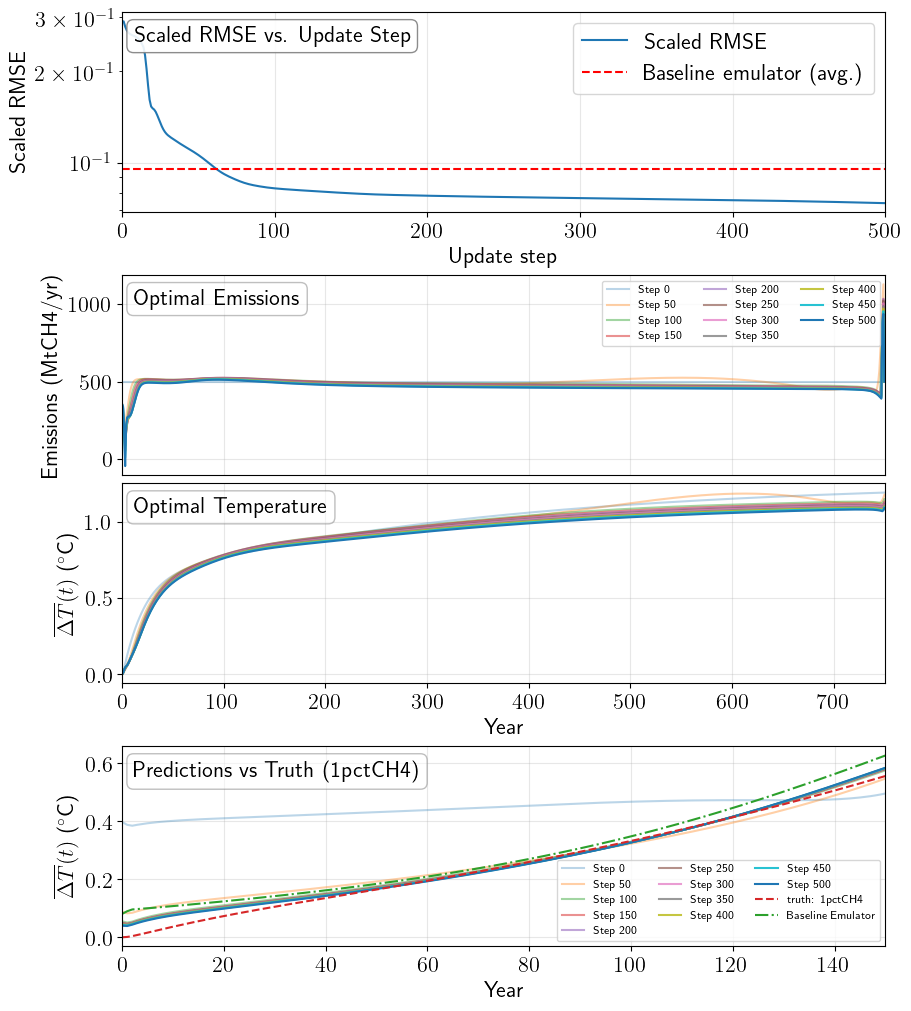

In [23]:
predict_plot = '1pctCH4'
utils_inverse.plot_inverse_results(
    results_CH4_DECK_constant,
    baseline_results['DECK']['mean'],
    active_agents=('CH4',),
    pred_scenario=predict_plot,
    baseline_preds=baseline_preds['DECK'][predict_plot]
)

In [24]:
emis_dict_valid = emis_dict_DECK_JAX.copy()
IC = 'ramp'

results_CH4_DECK_ramp = utils_inverse.optimize_emissions_inverse(
    emis_dict=emis_dict_valid,
    params0=params0,
    num_updates=500,
    step_size=1e3,
    momentum=0.9,
    nesterov=True,
    K_inner=400,
    lr_inner=5e-2,
    wd_inner=1e-2,
    checkpoint_path=f"checkpoints/ch4/inverse_{IC}_DECK_ch4_only.pkl",
    checkpoint_every=5,
    resume_if_exists=True,
    preds_every=1,
    active_agents=("CH4",),
    init_spec=IC,
    inactive_mode="zeros",
    T=751,
)

Found 500 updates in checkpoint, starting from here...


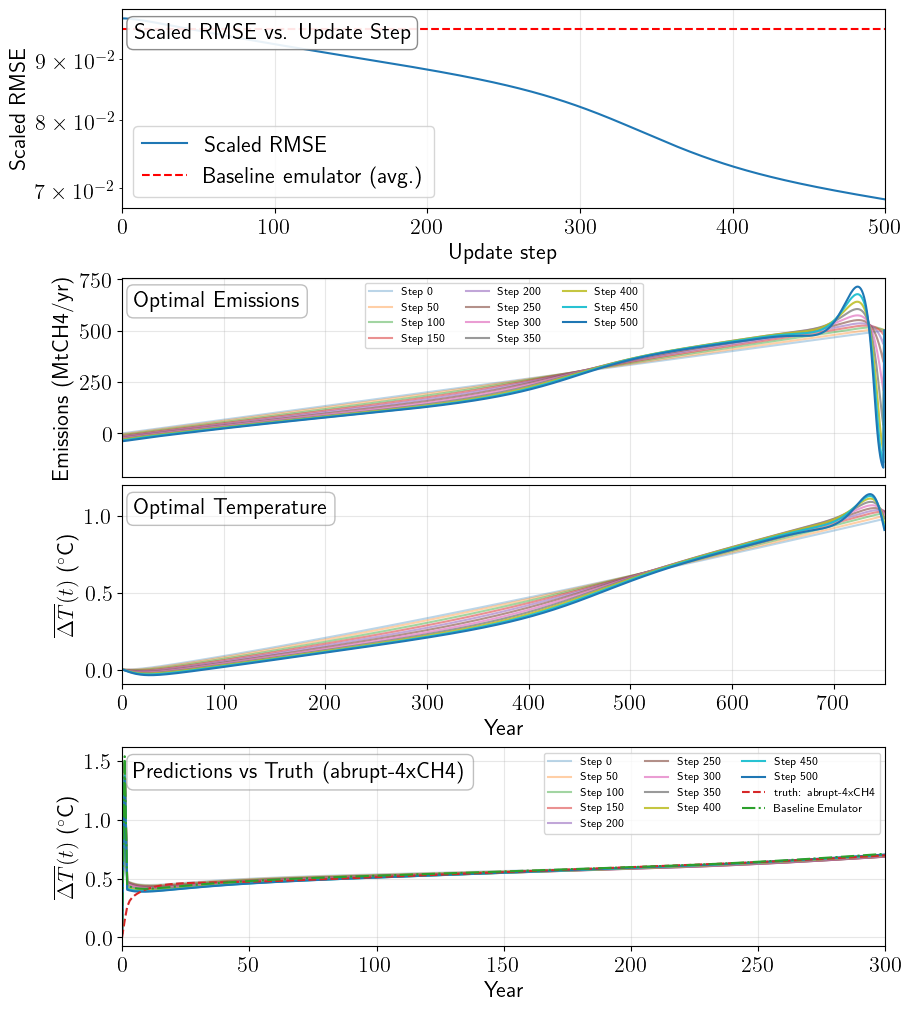

In [25]:
predict_plot = 'abrupt-4xCH4'
utils_inverse.plot_inverse_results(
    results_CH4_DECK_ramp,
    baseline_results['DECK']['mean'],
    active_agents=('CH4',),
    pred_scenario=predict_plot,
    baseline_preds=baseline_preds['DECK'][predict_plot]
)

In [26]:
emis_dict_valid = emis_dict_DECK_JAX.copy()
IC = 'gaussian'

results_CH4_DECK_gaussian = utils_inverse.optimize_emissions_inverse(
    emis_dict=emis_dict_valid,
    params0=params0,
    num_updates=500,
    step_size=1e3,
    momentum=0.9,
    nesterov=True,
    K_inner=400,
    lr_inner=5e-2,
    wd_inner=1e-2,
    checkpoint_path=f"checkpoints/ch4/inverse_{IC}_DECK_ch4_only.pkl",
    checkpoint_every=5,
    resume_if_exists=True,
    preds_every=1,
    active_agents=("CH4",),
    init_spec=IC,
    inactive_mode="zeros",
    T=751,
)

Found 500 updates in checkpoint, starting from here...


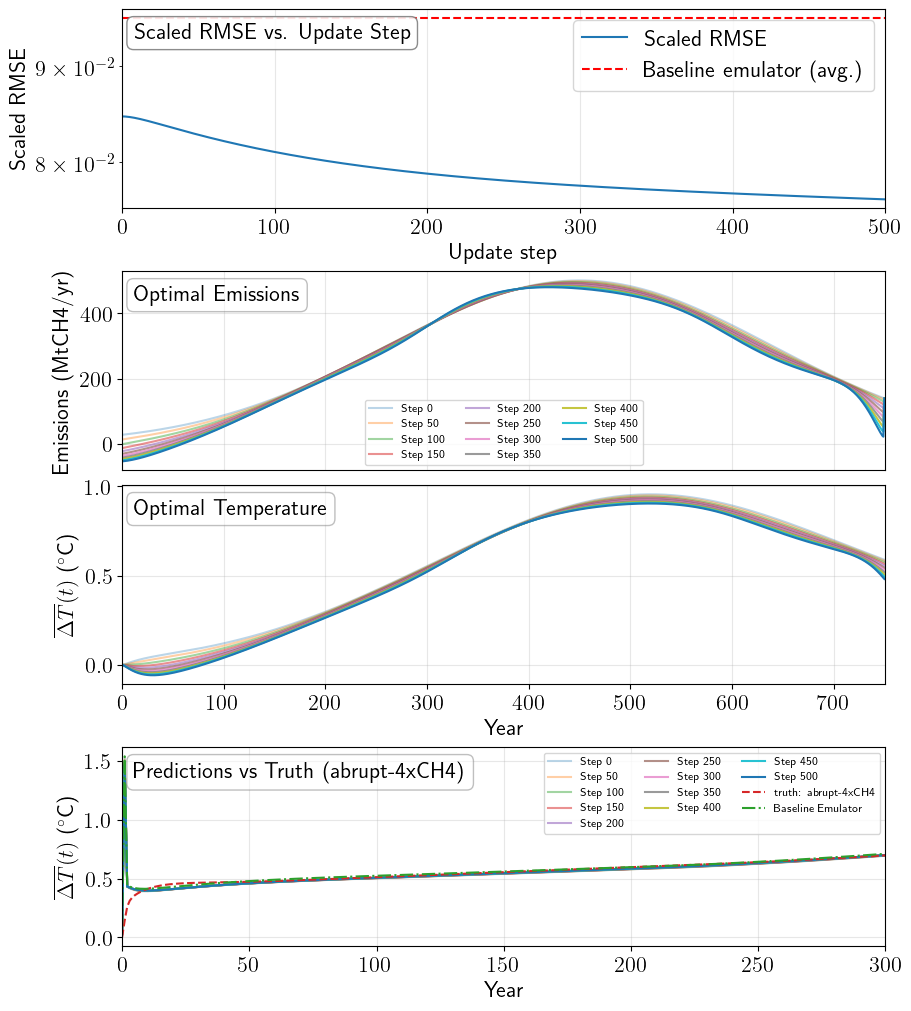

In [27]:
predict_plot = 'abrupt-4xCH4'
utils_inverse.plot_inverse_results(
    results_CH4_DECK_gaussian,
    baseline_results['DECK']['mean'],
    active_agents=('CH4',),
    pred_scenario=predict_plot,
    baseline_preds=baseline_preds['DECK'][predict_plot]
)

### 2f. Optimize training data for predictive skill over all scenarios, starting from constant, ramp, and Gaussian ICs

In [28]:
emis_dict_valid = emis_dict_calib_JAX.copy()
IC = 'constant'

results_CH4_all_constant = utils_inverse.optimize_emissions_inverse(
    emis_dict=emis_dict_valid,
    params0=params0,
    num_updates=500,
    step_size=1e3,
    momentum=0.9,
    nesterov=True,
    K_inner=400,
    lr_inner=5e-2,
    wd_inner=1e-2,
    checkpoint_path=f"checkpoints/ch4/inverse_{IC}_all_ch4_only.pkl",
    checkpoint_every=5,
    resume_if_exists=True,
    preds_every=1,
    active_agents=("CH4",),
    init_spec=IC,
    inactive_mode="zeros",
    T=751,
)

Found 500 updates in checkpoint, starting from here...


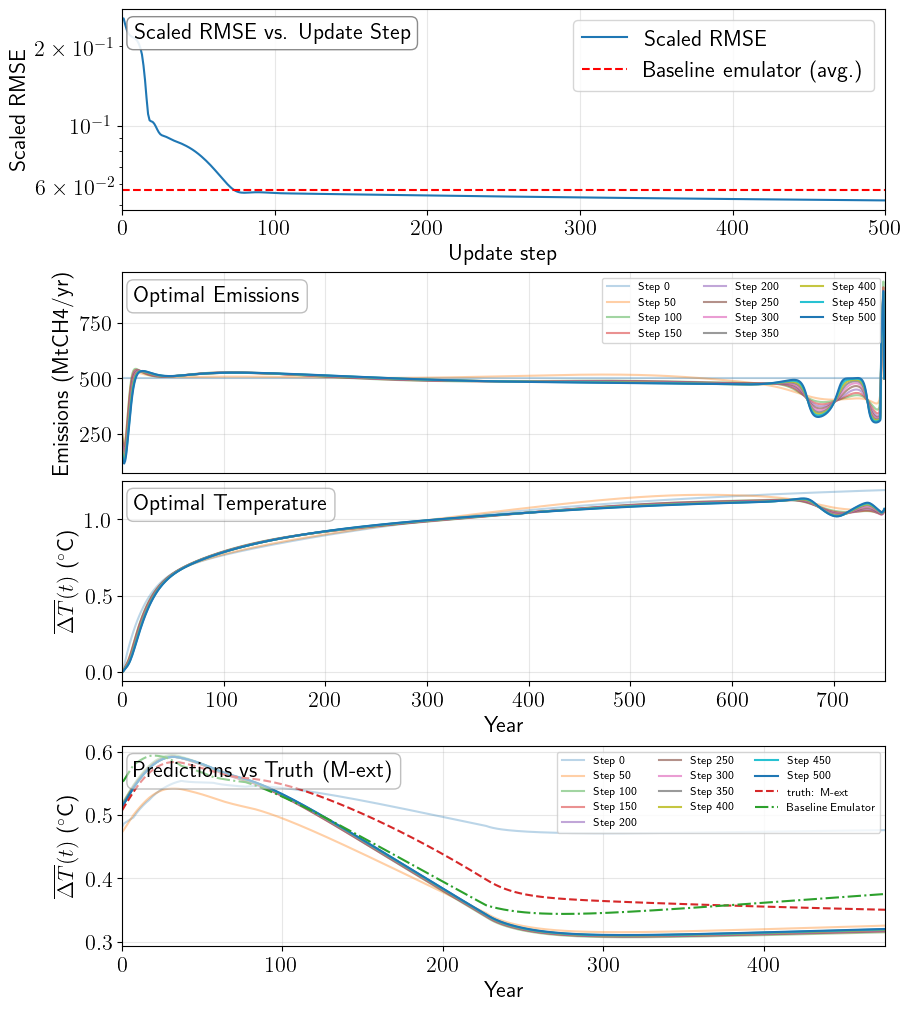

In [29]:
predict_plot = 'M-ext'
utils_inverse.plot_inverse_results(
    results_CH4_all_constant,
    baseline_results['All']['mean'],
    active_agents=('CH4',),
    pred_scenario=predict_plot,
    baseline_preds=baseline_preds['All'][predict_plot]
)

In [30]:
emis_dict_valid = emis_dict_calib_JAX.copy()
IC = 'ramp'

results_CH4_all_ramp = utils_inverse.optimize_emissions_inverse(
    emis_dict=emis_dict_valid,
    params0=params0,
    num_updates=500,
    step_size=1e3,
    momentum=0.9,
    nesterov=True,
    K_inner=400,
    lr_inner=5e-2,
    wd_inner=1e-2,
    checkpoint_path=f"checkpoints/ch4/inverse_{IC}_all_ch4_only.pkl",
    checkpoint_every=5,
    resume_if_exists=True,
    preds_every=1,
    active_agents=("CH4",),
    init_spec=IC,
    inactive_mode="zeros",
    T=751,
)

Found 500 updates in checkpoint, starting from here...


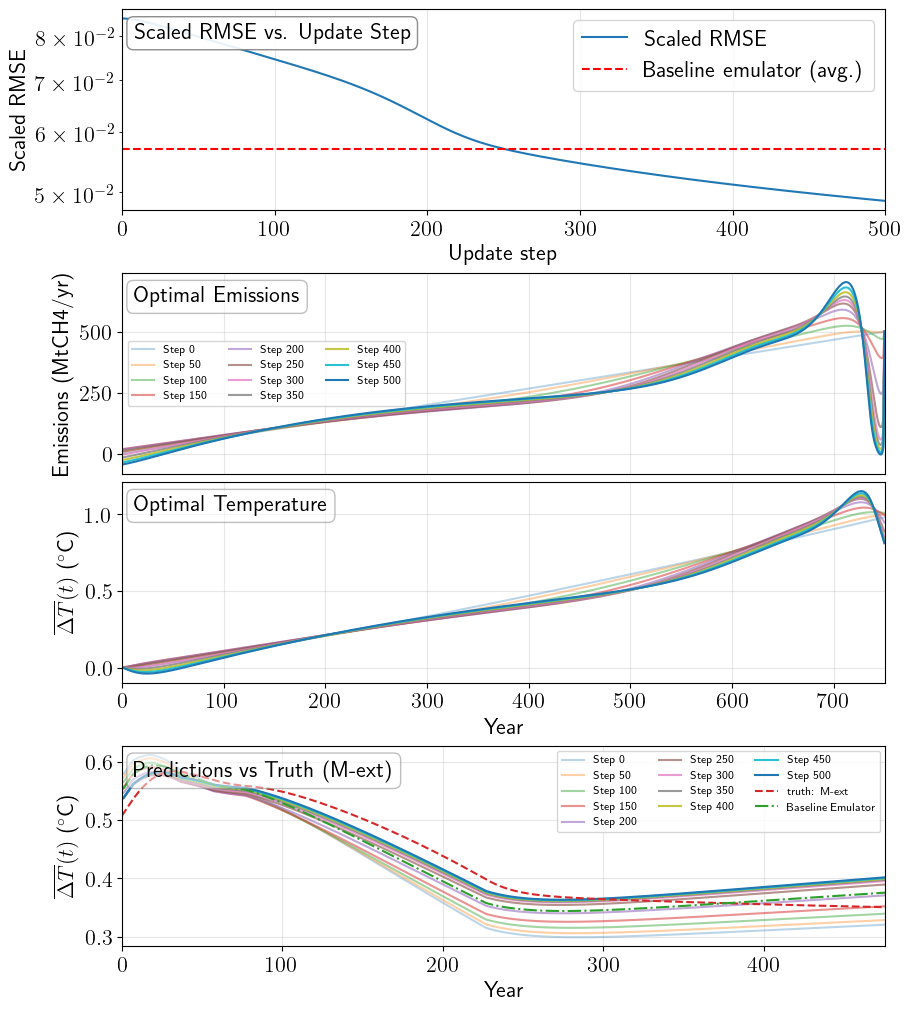

In [31]:
predict_plot = 'M-ext'
utils_inverse.plot_inverse_results(
    results_CH4_all_ramp,
    baseline_results['All']['mean'],
    active_agents=('CH4',),
    pred_scenario=predict_plot,
    baseline_preds=baseline_preds['All'][predict_plot]
)

In [32]:
emis_dict_valid = emis_dict_calib_JAX.copy()
IC = 'gaussian'

results_CH4_all_gaussian = utils_inverse.optimize_emissions_inverse(
    emis_dict=emis_dict_valid,
    params0=params0,
    num_updates=500,
    step_size=1e3,
    momentum=0.9,
    nesterov=True,
    K_inner=400,
    lr_inner=5e-2,
    wd_inner=1e-2,
    checkpoint_path=f"checkpoints/ch4/inverse_{IC}_all_ch4_only.pkl",
    checkpoint_every=5,
    resume_if_exists=True,
    preds_every=1,
    active_agents=("CH4",),
    init_spec=IC,
    inactive_mode="zeros",
    T=751,
)

Found 500 updates in checkpoint, starting from here...


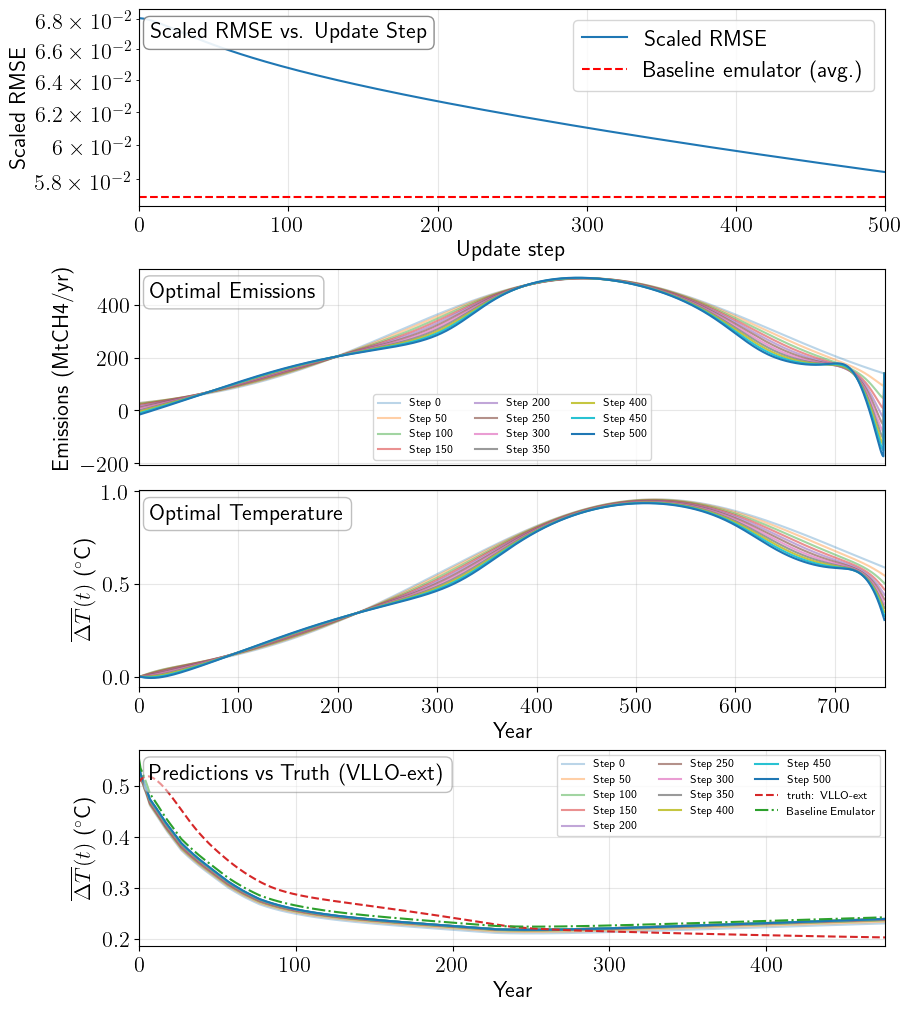

In [33]:
predict_plot = 'VLLO-ext'
utils_inverse.plot_inverse_results(
    results_CH4_all_gaussian,
    baseline_results['All']['mean'],
    active_agents=('CH4',),
    pred_scenario=predict_plot,
    baseline_preds=baseline_preds['All'][predict_plot]
)